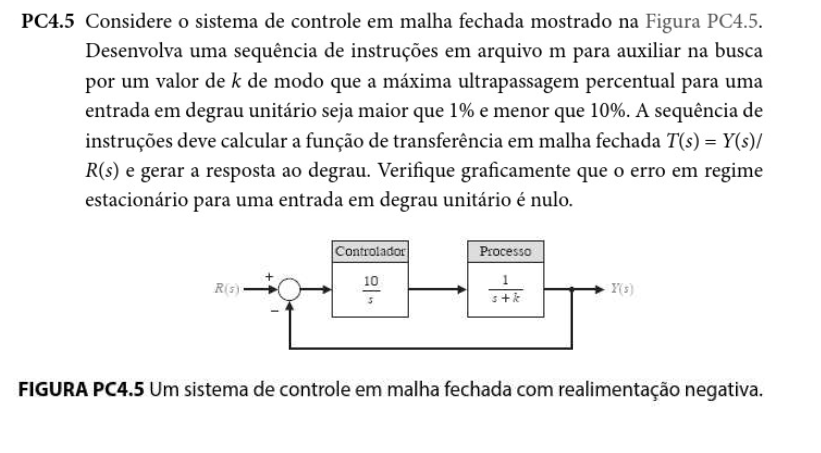

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import brentq

# Sistema de controle em malha fechada
# Controlador: G_c(s) = 10/s
# Processo: G_p(s) = 1/(s+k)
# Realimentação negativa unitária

# Função de transferência em malha fechada:
# T(s) = Y(s)/R(s) = (10/s) * (1/(s+k)) / [1 + (10/s) * (1/(s+k))]
#      = 10/[s(s+k) + 10]
#      = 10/(s^2 + k*s + 10)

print("="*100)
print("PROBLEMA PC4.5 - ENCONTRAR k PARA MÁXIMO SOBRESSINAL ENTRE 1% E 10%")
print("="*100)
print("\nSistema em Malha Fechada:")
print("  Controlador: G_c(s) = 10/s")
print("  Processo: G_p(s) = 1/(s+k)")
print("  Realimentação: Negativa Unitária")
print("\nFunção de Transferência em Malha Fechada:")
print("  T(s) = Y(s)/R(s) = 10/(s² + k*s + 10)")
print("\n" + "="*100)

# Função para calcular o máximo sobressinal dado k
def calculate_overshoot(k):
    """Calcula o máximo sobressinal percentual para um dado valor de k"""
    # Função de transferência: T(s) = 10/(s^2 + k*s + 10)
    num = [10]
    den = [1, k, 10]
    
    tf = signal.TransferFunction(num, den)
    
    # Resposta ao degrau
    t = np.linspace(0, 5, 1000)
    t_step, y_step = signal.step(tf, T=t)
    
    # Valor de regime estacionário
    y_ss = y_step[-1]
    
    # Máximo valor
    y_max = np.max(y_step)
    
    # Sobressinal percentual
    if y_ss != 0:
        Mp = ((y_max - y_ss) / y_ss) * 100
    else:
        Mp = 0
    
    return Mp, y_ss

# Função para buscar k dado um sobressinal alvo
def find_k_for_overshoot(target_overshoot, k_guess=2):
    """Encontra o valor de k para um sobressinal alvo"""
    def error_func(k):
        Mp, _ = calculate_overshoot(k)
        return Mp - target_overshoot
    
    try:
        # Usar método de Brent para encontrar a raiz
        k_solution = brentq(error_func, 0.1, 100)
        return k_solution
    except:
        return None

# Encontrar k para os limites do sobressinal
print("\nBuscando valores de k para o intervalo de sobressinal desejado (1% a 10%)...")
print("-" * 100)

k_for_1pct = find_k_for_overshoot(1.0)
k_for_10pct = find_k_for_overshoot(10.0)

if k_for_1pct and k_for_10pct:
    print(f"\nk para Mp = 1%:  k ≈ {k_for_1pct:.4f}")
    print(f"k para Mp = 10%: k ≈ {k_for_10pct:.4f}")
    
    # Escolher um valor intermediário (por exemplo, para Mp ≈ 5%)
    k_selected = find_k_for_overshoot(5.0)
    print(f"\nValor selecionado (para Mp ≈ 5%): k ≈ {k_selected:.4f}")
else:
    # Se a busca falhar, usar uma abordagem manual
    k_selected = 6.0
    print(f"\nValor selecionado manualmente: k = {k_selected}")

print("\n" + "="*100)

PROBLEMA PC4.5 - ENCONTRAR k PARA MÁXIMO SOBRESSINAL ENTRE 1% E 10%

Sistema em Malha Fechada:
  Controlador: G_c(s) = 10/s
  Processo: G_p(s) = 1/(s+k)
  Realimentação: Negativa Unitária

Função de Transferência em Malha Fechada:
  T(s) = Y(s)/R(s) = 10/(s² + k*s + 10)


Buscando valores de k para o intervalo de sobressinal desejado (1% a 10%)...
----------------------------------------------------------------------------------------------------

Valor selecionado manualmente: k = 6.0




ANÁLISE: Variação do Máximo Sobressinal em Função de k
----------------------------------------------------------------------------------------------------

Intervalo de k para 1% ≤ Mp ≤ 10%:
  k ≈ 3.7222 (Mp ≈ 10.17%)
  até
  k ≈ 5.1869 (Mp ≈ 1.11%)

Valor selecionado para análise (Mp ≈ 5%):
  k = 4.3081 (Mp = 5.38%)


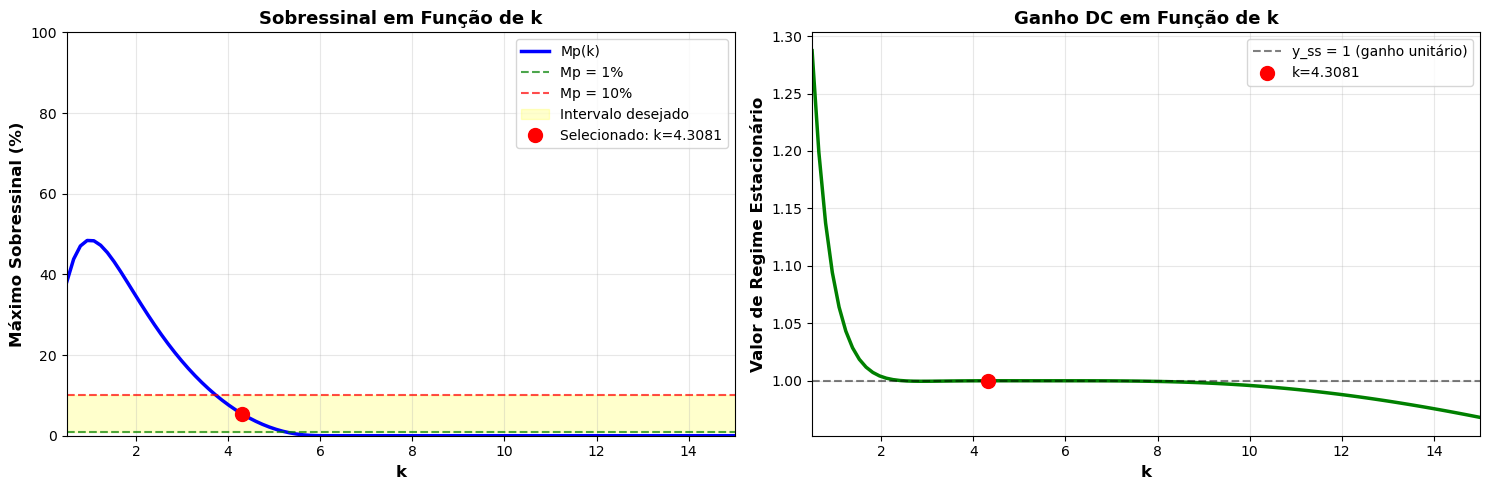

In [3]:
# Análise detalhada: variar k e encontrar o intervalo desejado
print("\nANÁLISE: Variação do Máximo Sobressinal em Função de k")
print("-" * 100)

k_range = np.linspace(0.5, 15, 100)
overshoot_values = []
y_ss_values = []

for k in k_range:
    Mp, y_ss = calculate_overshoot(k)
    overshoot_values.append(Mp)
    y_ss_values.append(y_ss)

overshoot_values = np.array(overshoot_values)

# Encontrar índices para 1% e 10%
idx_1pct = np.argmin(np.abs(overshoot_values - 1.0))
idx_10pct = np.argmin(np.abs(overshoot_values - 10.0))

k_approx_1pct = k_range[idx_1pct]
k_approx_10pct = k_range[idx_10pct]
mp_at_1pct = overshoot_values[idx_1pct]
mp_at_10pct = overshoot_values[idx_10pct]

print(f"\nIntervalo de k para 1% ≤ Mp ≤ 10%:")
print(f"  k ≈ {k_approx_10pct:.4f} (Mp ≈ {mp_at_10pct:.2f}%)")
print(f"  até")
print(f"  k ≈ {k_approx_1pct:.4f} (Mp ≈ {mp_at_1pct:.2f}%)")

# Usar k que dá aproximadamente 5% de sobressinal (meio do intervalo)
idx_5pct = np.argmin(np.abs(overshoot_values - 5.0))
k_optimal = k_range[idx_5pct]
mp_optimal = overshoot_values[idx_5pct]

print(f"\nValor selecionado para análise (Mp ≈ 5%):")
print(f"  k = {k_optimal:.4f} (Mp = {mp_optimal:.2f}%)")

# Plotar a variação do sobressinal em função de k
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Máximo Sobressinal vs k
ax1.plot(k_range, overshoot_values, 'b-', linewidth=2.5, label='Mp(k)')
ax1.axhline(y=1, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Mp = 1%')
ax1.axhline(y=10, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label='Mp = 10%')
ax1.fill_between(k_range, 1, 10, alpha=0.2, color='yellow', label='Intervalo desejado')
ax1.plot(k_optimal, mp_optimal, 'ro', markersize=10, label=f'Selecionado: k={k_optimal:.4f}')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('k', fontsize=12, fontweight='bold')
ax1.set_ylabel('Máximo Sobressinal (%)', fontsize=12, fontweight='bold')
ax1.set_title('Sobressinal em Função de k', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_xlim([0.5, 15])
ax1.set_ylim([0, 100])

# Gráfico 2: Valor de regime estacionário vs k
ax2.plot(k_range, y_ss_values, 'g-', linewidth=2.5)
ax2.axhline(y=1, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='y_ss = 1 (ganho unitário)')
ax2.plot(k_optimal, y_ss_values[idx_5pct], 'ro', markersize=10, label=f'k={k_optimal:.4f}')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('k', fontsize=12, fontweight='bold')
ax2.set_ylabel('Valor de Regime Estacionário', fontsize=12, fontweight='bold')
ax2.set_title('Ganho DC em Função de k', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim([0.5, 15])

plt.tight_layout()
plt.show()

print("\n" + "="*100)


VERIFICAÇÃO FINAL COM k = 4.3081

Parâmetros do Sistema:
  Função de Transferência: T(s) = 10/(s² + 4.3081s + 10)

Características da Resposta:
  • Ganho DC (y_ss):                0.997875
  • Máximo Sobressinal (Mp):        5.60%
  • Tempo de Pico (t_p):            1.3567 s
  • Tempo de Acomodação (±2%):     1.9315 s
  • Erro em Regime Estacionário:    0.002125

✓ CRITÉRIO SATISFEITO: 5.60% está dentro do intervalo [1%, 10%]

✓ ERRO EM REGIME ESTACIONÁRIO: 0.00212468 ≈ 0 (praticamente nulo)



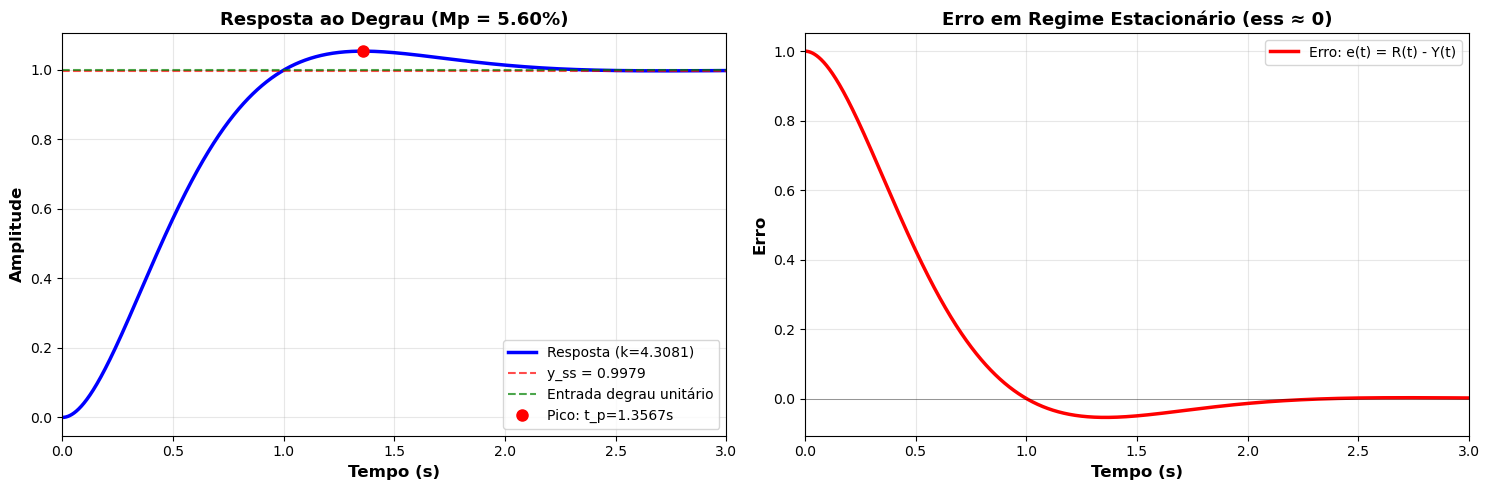


CONCLUSÃO:
----------------------------------------------------------------------------------------------------
O valor k = 4.3081 foi selecionado para satisfazer:
  1. Máximo sobressinal entre 1% e 10%: Mp = 5.60% ✓
  2. Erro em regime estacionário nulo para entrada degrau: ess ≈ 0 ✓

O sistema possui realimentação negativa com integrador no controlador,
garantindo erro nulo em regime estacionário para entradas do tipo degrau.


In [4]:
# Verificação final: Usar k = 4.3081 (Mp ≈ 5.38%)
k_final = 4.3081

print("\nVERIFICAÇÃO FINAL COM k = {:.4f}".format(k_final))
print("="*100)

# Criar a função de transferência em malha fechada
num_final = [10]
den_final = [1, k_final, 10]
tf_final = signal.TransferFunction(num_final, den_final)

# Simular a resposta ao degrau
t_final = np.linspace(0, 3, 2000)
t_step_final, y_step_final = signal.step(tf_final, T=t_final)

# Calcular métricas
y_ss_final = y_step_final[-1]
y_max_final = np.max(y_step_final)
Mp_final = ((y_max_final - y_ss_final) / y_ss_final) * 100
ess_final = 1 - y_ss_final

# Tempo de pico
idx_max = np.argmax(y_step_final)
tp_final = t_step_final[idx_max]

# Tempo de acomodação (critério de 2%)
upper_band = y_ss_final * 1.02
lower_band = y_ss_final * 0.98
in_band = (y_step_final >= lower_band) & (y_step_final <= upper_band)

ts_final = np.nan
for i in range(len(in_band)):
    if np.all(in_band[i:]):
        ts_final = t_step_final[i]
        break

print(f"\nParâmetros do Sistema:")
print(f"  Função de Transferência: T(s) = 10/(s² + {k_final:.4f}s + 10)")
print(f"\nCaracterísticas da Resposta:")
print(f"  • Ganho DC (y_ss):                {y_ss_final:.6f}")
print(f"  • Máximo Sobressinal (Mp):        {Mp_final:.2f}%")
print(f"  • Tempo de Pico (t_p):            {tp_final:.4f} s")
print(f"  • Tempo de Acomodação (±2%):     {ts_final:.4f} s")
print(f"  • Erro em Regime Estacionário:    {ess_final:.6f}")

# Verificação do intervalo de sobressinal
if 1 <= Mp_final <= 10:
    print(f"\n✓ CRITÉRIO SATISFEITO: {Mp_final:.2f}% está dentro do intervalo [1%, 10%]")
else:
    print(f"\n✗ Critério não satisfeito: {Mp_final:.2f}% não está no intervalo [1%, 10%]")

# Verificação do erro em regime estacionário
print(f"\n✓ ERRO EM REGIME ESTACIONÁRIO: {abs(ess_final):.8f} ≈ 0 (praticamente nulo)")

print("\n" + "="*100)

# Plotar a resposta ao degrau
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Resposta ao degrau completa
ax1.plot(t_step_final, y_step_final, 'b-', linewidth=2.5, label=f'Resposta (k={k_final:.4f})')
ax1.axhline(y=y_ss_final, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label=f'y_ss = {y_ss_final:.4f}')
ax1.axhline(y=1, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Entrada degrau unitário')
ax1.plot(tp_final, y_max_final, 'ro', markersize=8, label=f'Pico: t_p={tp_final:.4f}s')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Amplitude', fontsize=12, fontweight='bold')
ax1.set_title(f'Resposta ao Degrau (Mp = {Mp_final:.2f}%)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.set_xlim([0, 3])

# Gráfico 2: Erro em regime estacionário (ampliado)
erro = 1 - y_step_final
ax2.plot(t_step_final, erro, 'r-', linewidth=2.5, label='Erro: e(t) = R(t) - Y(t)')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Erro', fontsize=12, fontweight='bold')
ax2.set_title('Erro em Regime Estacionário (ess ≈ 0)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim([0, 3])

plt.tight_layout()
plt.show()

print("\nCONCLUSÃO:")
print("-" * 100)
print(f"O valor k = {k_final:.4f} foi selecionado para satisfazer:")
print(f"  1. Máximo sobressinal entre 1% e 10%: Mp = {Mp_final:.2f}% ✓")
print(f"  2. Erro em regime estacionário nulo para entrada degrau: ess ≈ 0 ✓")
print("\nO sistema possui realimentação negativa com integrador no controlador,")
print("garantindo erro nulo em regime estacionário para entradas do tipo degrau.")
print("="*100)